# Z score treatment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
df=pd.read_csv("placement.csv")
df.sample(10)

,cgpa,placement_exam_marks,placed
953,6.91,44.0,0
781,7.17,49.0,1
168,6.51,37.0,1
968,6.84,26.0,0
23,6.05,11.0,0
958,7.43,11.0,0
204,7.01,5.0,1
424,6.91,30.0,0
157,7.07,81.0,1
866,7.29,35.0,0


/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: divide by zero encountered in dot
  c = dot(X, X_T.conj())
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: overflow encountered in dot
  c = dot(X, X_T.conj())
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: divide by zero encountered in dot
  c = dot(X, X_T.conj())
/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2911: RuntimeWarning: overflow encountered in dot
  c = dot(X, X_T.conj())
/Us

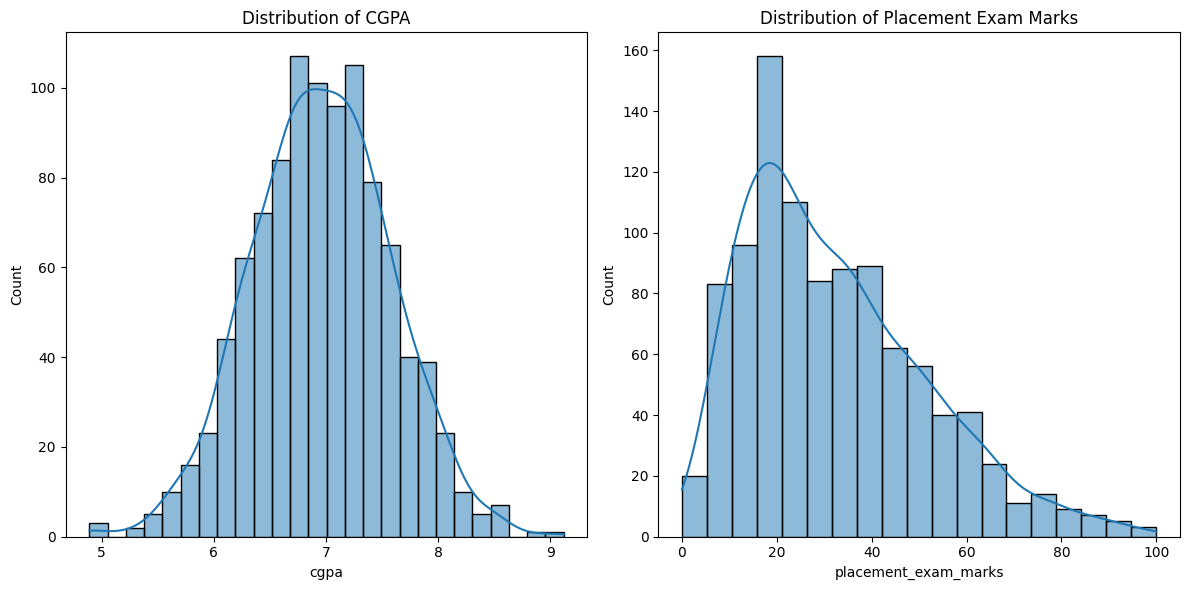

In [6]:
plt.figure(figsize=(12, 6))

# First subplot
plt.subplot(1, 2, 1)
sns.histplot(df["cgpa"], kde=True)
plt.title("Distribution of CGPA")

# Second subplot
plt.subplot(1, 2, 2)
sns.histplot(df["placement_exam_marks"], kde=True)
plt.title("Distribution of Placement Exam Marks")

plt.tight_layout()
plt.show()

In [7]:
print("mean of cgpa", df["cgpa"].mean())
print("median of cgpa", df["cgpa"].median())
print("SD of cgpa", df["cgpa"].std())
print("max of cgpa", df["cgpa"].max())
print("min of cgpa", df["cgpa"].min())

mean of cgpa 6.96124
median of cgpa 6.96
SD of cgpa 0.6158978751323896
max of cgpa 9.12
min of cgpa 4.89


In [8]:
print("higest allowed : ",df["cgpa"].mean() + 3*df["cgpa"].std())
print("lowest allowed : ",df["cgpa"].mean() - 3*df["cgpa"].std())

higest allowed :  8.808933625397168
lowest allowed :  5.113546374602832


In [11]:
df[(df["cgpa"]> 8.80) | (df["cgpa"]<5.11)]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [12]:
upper_limit=df["cgpa"].mean() + 3*df["cgpa"].std()
lower_limit=df["cgpa"].mean() - 3*df["cgpa"].std()

In [14]:
df["cgpa"] = np.where(
    df["cgpa"]>upper_limit,upper_limit,
    np.where(df["cgpa"]<lower_limit,lower_limit,
    df["cgpa"])
)

In [15]:
df.tail(20)

,cgpa,placement_exam_marks,placed
980,6.180000,27.0,0
981,8.060000,37.0,0
982,6.870000,22.0,0
983,6.810000,11.0,1
984,6.890000,16.0,1
985,7.100000,26.0,0
986,7.090000,19.0,1
987,6.770000,62.0,0
988,5.640000,37.0,1
989,6.230000,31.0,0


# IQR METHOD

In [16]:
df["placement_exam_marks"].skew()

np.float64(0.8356419499466834)

In [17]:
df["placement_exam_marks"].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

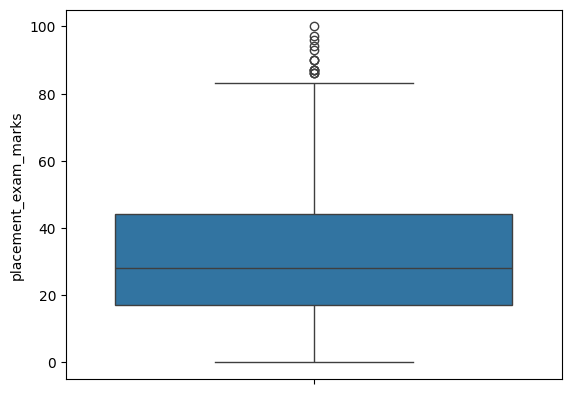

In [18]:
sns.boxplot(df["placement_exam_marks"])

In [19]:
percentile25=df["placement_exam_marks"].quantile(0.25)
percentile75=df["placement_exam_marks"].quantile(0.75)

In [20]:
iqr = percentile75-percentile25

In [23]:
upper_limit= percentile75 +1.5*iqr
lower_limit= percentile25 -1.5*iqr
upper_limit,lower_limit

(np.float64(84.5), np.float64(-23.5))

In [22]:
df[(df["placement_exam_marks"]>upper_limit) | (df["placement_exam_marks"]<lower_limit)]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [25]:
df["placement_exam_marks"] = np.where(
    df["placement_exam_marks"]>upper_limit,upper_limit,
    np.where(df["placement_exam_marks"]<lower_limit,lower_limit,
    df["placement_exam_marks"])
)

In [28]:
df.iloc[9]

cgpa                     7.75
placement_exam_marks    84.50
placed                   1.00
Name: 9, dtype: float64